# استراتژی نگهداری پویای FD001 با CNN–BiLSTM–Attention — checkpoint بدون Drive

ساختار مدل، تقسیم داده‌ها، پیش‌پردازش و منطق استراتژی همان نسخه اصلی است. پس از پایان هر seed، یک checkpoint **تجمعی** دانلود می‌شود. پس از قطع Runtime، آخرین checkpoint را همراه سه فایل FD001 بارگذاری کنید تا فقط seedهای باقی‌مانده اجرا شوند.


In [2]:
# سلول 1: کتابخانه‌ها و تنظیمات — بدون Google Drive
import os, gc, time, random, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.stats import gamma as gamma_dist
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv1D, Dropout, Bidirectional, LSTM, Dense, Softmax, Multiply, Lambda
from tensorflow.keras.optimizers import Adam
from google.colab import files

warnings.filterwarnings('ignore')

# pilot = یک اجرا برای کنترل؛ final = چهل اجرای قابل گزارش
RUN_MODE = 'final'

# در حالت نهایی پس از هر چند اجرای کامل‌شده، checkpoint تجمعی دانلود شود.
# مقدار 1 امن‌ترین حالت است. برای دانلود کمتر می‌توان آن را 2 یا 5 قرار داد.
CHECKPOINT_EVERY = 1
AUTO_DOWNLOAD_CHECKPOINT = True

MAX_RUL = 125.0
WINDOW_SIZE = 25
INPUT_DIMS = 14
CNN_FILTERS = 64
KERNEL_SIZE = 3
BILSTM_UNITS = 64
ATTENTION_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001
BATCH_SIZE = 256
EPOCHS = 64

ALL_SEEDS = [11 * i for i in range(1, 41)]
SEEDS = ALL_SEEDS[:1] if RUN_MODE == 'pilot' else ALL_SEEDS
N_RUNS = len(SEEDS)

GAMMA_RATE = 2.0
GAMMA_SHAPE = 3
MISSION_CYCLE = 3.770
LEAD_TIME = 20.0
INSPECTION_INTERVAL = 5
CP = 100.0
CF = 500.0
COS = 10.0
RELIABILITY_THRESHOLD = 0.8

OUTPUT_DIR = Path('/content/FD001_Attention_Dynamic_Maintenance_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('Run mode:', RUN_MODE, '| runs:', N_RUNS)
if RUN_MODE == 'pilot':
    print('هشدار: خروجی pilot برای گزارش پایان‌نامه نیست.')


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Run mode: final | runs: 40


## بارگذاری داده‌ها

پس از اجرای سلول بعد، سه فایل `train_FD001.txt`، `test_FD001.txt` و `RUL_FD001.txt` را هم‌زمان انتخاب کن. برای استراتژی چرخه‌ای، مسیر کامل موتورهای فایل آموزش استفاده می‌شود؛ فایل‌های آزمون رسمی فقط برای کنترل ابعاد و حفظ مجموعه کامل پروژه بارگذاری می‌شوند.

In [3]:
# سلول 2: بارگذاری سه فایل FD001 و checkpoint اختیاری
print('سه فایل FD001 را انتخاب کنید. اگر ادامه اجرای قطع‌شده است، آخرین checkpoint را هم انتخاب کنید.')
uploaded = files.upload()

def find_uploaded(prefix):
    matches = [name for name in uploaded if name.lower().startswith(prefix.lower())]
    if not matches:
        raise FileNotFoundError(f'فایل شروع‌شونده با {prefix} بارگذاری نشده است.')
    return matches[0]

TRAIN_FILE = find_uploaded('train_FD001')
TEST_FILE = find_uploaded('test_FD001')
RUL_FILE = find_uploaded('RUL_FD001')
checkpoint_candidates = [name for name in uploaded if name.lower().endswith('.npz') and 'checkpoint' in name.lower()]
UPLOADED_CHECKPOINT = checkpoint_candidates[0] if checkpoint_candidates else None
if len(checkpoint_candidates) > 1:
    raise ValueError('فقط آخرین فایل checkpoint را انتخاب کنید.')

train_raw = np.loadtxt(TRAIN_FILE)
official_test_raw = np.loadtxt(TEST_FILE)
official_test_rul = np.loadtxt(RUL_FILE).reshape(-1)

assert train_raw.shape == (20631, 26), train_raw.shape
assert official_test_raw.shape == (13096, 26), official_test_raw.shape
assert official_test_rul.shape == (100,), official_test_rul.shape
print('ابعاد داده‌ها صحیح است.')
print('Checkpoint:', UPLOADED_CHECKPOINT if UPLOADED_CHECKPOINT else 'وجود ندارد؛ اجرا از ابتدا شروع می‌شود.')


سه فایل FD001 را انتخاب کنید. اگر ادامه اجرای قطع‌شده است، آخرین checkpoint را هم انتخاب کنید.


Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt
ابعاد داده‌ها صحیح است.
Checkpoint: وجود ندارد؛ اجرا از ابتدا شروع می‌شود.


## پیش‌پردازش بدون نشت اطلاعات

موتورهای ۱ تا ۸۰ مبنای برازش Min-Max هستند و همان تبدیل روی موتورهای ۸۱ تا ۱۰۰ اعمال می‌شود. ستون‌های ثابت حذف می‌شوند؛ فهرست حذف دقیقاً مطابق کد نویسنده است و پس از نگه‌داشتن شناسه و چرخه، ۱۴ حسگر باقی می‌ماند.

In [4]:
# سلول 3: تقسیم موتورمحور، مقیاس‌بندی و انتخاب حسگرها
TRAIN_ENGINE_IDS = np.arange(1, 81)
STRATEGY_ENGINE_IDS = np.arange(81, 101)
DELETE_COLUMNS = [2, 3, 4, 5, 9, 10, 14, 20, 22, 23]

train_mask = np.isin(train_raw[:, 0].astype(int), TRAIN_ENGINE_IDS)
strategy_mask = np.isin(train_raw[:, 0].astype(int), STRATEGY_ENGINE_IDS)

raw_80 = train_raw[train_mask].copy()
raw_20 = train_raw[strategy_mask].copy()

# شناسه و چرخه مقیاس نمی‌شوند؛ پارامترهای scaler فقط از موتورهای 1 تا 80 می‌آیند.
scaler = MinMaxScaler()
raw_80[:, 2:] = scaler.fit_transform(raw_80[:, 2:])
raw_20[:, 2:] = scaler.transform(raw_20[:, 2:])

data_80 = np.delete(raw_80, DELETE_COLUMNS, axis=1)
data_20 = np.delete(raw_20, DELETE_COLUMNS, axis=1)

assert data_80.shape[1] == 16  # engine, cycle, 14 sensors
assert data_20.shape[1] == 16
print("Training engines:", np.unique(data_80[:, 0].astype(int)))
print("Strategy engines:", np.unique(data_20[:, 0].astype(int)))
print("Number of sensor inputs:", data_80.shape[1] - 2)

Training engines: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80]
Strategy engines: [ 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100]
Number of sensor inputs: 14


In [5]:
# سلول 4: ساخت پنجره‌های آموزش و پیش‌بینی چرخه‌ای
def make_training_windows(data, window_size=25, max_rul=125.0):
    X, y = [], []
    for engine_id in np.unique(data[:, 0].astype(int)):
        engine = data[data[:, 0].astype(int) == engine_id]
        engine = engine[np.argsort(engine[:, 1])]
        lifetime = int(engine[-1, 1])
        for start in range(len(engine) - window_size + 1):
            end = start + window_size
            end_cycle = int(engine[end - 1, 1])
            rul = min(lifetime - end_cycle, max_rul)
            X.append(engine[start:end, 2:])
            y.append(rul / max_rul)
    return np.asarray(X, np.float32), np.asarray(y, np.float32)


def make_cycle_windows(data, window_size=25, max_rul=125.0):
    X, engine_ids, cycles, true_rul, capped_rul, lifetimes = [], [], [], [], [], []
    for engine_id in np.unique(data[:, 0].astype(int)):
        engine = data[data[:, 0].astype(int) == engine_id]
        engine = engine[np.argsort(engine[:, 1])]
        lifetime = int(engine[-1, 1])
        for end in range(window_size, len(engine) + 1):
            cycle = int(engine[end - 1, 1])
            rul = float(lifetime - cycle)
            X.append(engine[end-window_size:end, 2:])
            engine_ids.append(engine_id)
            cycles.append(cycle)
            true_rul.append(rul)
            capped_rul.append(min(rul, max_rul))
            lifetimes.append(lifetime)
    return tuple(np.asarray(v) for v in (X, engine_ids, cycles, true_rul, capped_rul, lifetimes))


trainData, trainTarget = make_training_windows(data_80, WINDOW_SIZE, MAX_RUL)
(strategyData, test_engine_ids, test_cycles, test_true_rul,
 test_true_rul_capped, test_lifetimes) = make_cycle_windows(data_20, WINDOW_SIZE, MAX_RUL)

strategyData = strategyData.astype(np.float32)
test_engine_ids = test_engine_ids.astype(int)
test_cycles = test_cycles.astype(int)
test_lifetimes = test_lifetimes.astype(int)

print("trainData:", trainData.shape)
print("strategyData:", strategyData.shape)
print("strategy engines:", len(np.unique(test_engine_ids)))
assert trainData.shape[1:] == (25, 14)
assert strategyData.shape[1:] == (25, 14)

trainData: (14218, 25, 14)
strategyData: (4013, 25, 14)
strategy engines: 20


In [6]:
# سلول 5: مدل CNN–BiLSTM با توجه افزایشی زمانی
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def build_model(dropout_rate=DROPOUT_RATE):
    inputs = Input(shape=(WINDOW_SIZE, INPUT_DIMS), name='sensor_window')
    x = Conv1D(CNN_FILTERS, KERNEL_SIZE, activation='relu', padding='same', name='conv1d_features')(inputs)
    x = Dropout(dropout_rate, name='dropout_after_cnn')(x)
    h = Bidirectional(
        LSTM(BILSTM_UNITS, return_sequences=True),
        merge_mode='concat', name='bidirectional_lstm'
    )(x)
    h = Dropout(dropout_rate, name='dropout_after_bilstm')(h)

    # u_t=tanh(W_a h_t+b_a), e_t=v_a^T u_t, alpha=softmax(e)
    u = Dense(ATTENTION_UNITS, activation='tanh', name='attention_hidden')(h)
    e = Dense(1, use_bias=False, name='attention_score')(u)
    alpha = Softmax(axis=1, name='attention_weights')(e)
    weighted = Multiply(name='weighted_bilstm_outputs')([h, alpha])
    context = Lambda(lambda z: tf.reduce_sum(z, axis=1), name='context_vector')(weighted)
    outputs = Dense(1, activation='linear', name='rul_output')(context)

    model = Model(inputs, outputs, name='CNN_BiLSTM_Temporal_Additive_Attention')
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mse')
    return model

tf.keras.backend.clear_session()
set_seed(SEEDS[0])
sample_model = build_model()
sample_model.summary()
assert tuple(sample_model.get_layer('attention_weights').output.shape) == (None, WINDOW_SIZE, 1)
del sample_model
tf.keras.backend.clear_session()


Model: "CNN_BiLSTM_Temporal_Additive_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_window       │ (None, 25, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_features     │ (None, 25, 64)    │      2,752 │ sensor_window[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_after_cnn   │ (None, 25, 64)    │          0 │ conv1d_features[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm  │ (None, 25, 128)   │     66,048 │ dropout_after_cn… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_after_bils… │ (None, 25, 128)   │          0 │ bidirectional_ls… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_hidden    │ (None, 25, 64)    │      8,256 │ dropout_after_bi… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 25, 1)     │         64 │ attention_hidden… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 25, 1)     │          0 │ attention_score[… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_bilstm_ou… │ (None, 25, 128)   │          0 │ dropout_after_bi… │
│ (Multiply)          │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 128)       │          0 │ weighted_bilstm_… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │        129 │ context_vector[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,249 (301.75 KB)

 Trainable params: 77,249 (301.75 KB)

 Non-trainable params: 0 (0.00 B)

## آموزش مستقل با checkpoint تجمعی

خروجی ۶۴ Epoch نمایش داده نمی‌شود؛ فقط شروع و پایان هر seed دیده می‌شود. checkpoint بعد از اجرای کامل seed ساخته می‌شود و هیچ مدل نیمه‌آموزش‌دیده‌ای در نتایج وارد نمی‌شود.


In [7]:
# سلول 6: آموزش 1 یا 40 اجرا با Resume و checkpoint بدون Drive
checkpoint_path = Path('/content/attention_strategy_cumulative_checkpoint.npz')

def save_checkpoint():
    temp_path = Path('/content/attention_strategy_cumulative_checkpoint_temporary.npz')
    np.savez_compressed(
        temp_path,
        run_mode=np.asarray(RUN_MODE),
        completed_seeds=np.asarray(completed_seeds, dtype=int),
        predictions=np.asarray(run_predictions, dtype=np.float32),
        rmse=np.asarray(run_rmse_values, dtype=float),
        training_times=np.asarray(run_training_times, dtype=float),
        final_losses=np.asarray(run_final_losses, dtype=float),
        loss_histories=np.asarray(history_losses, dtype=np.float32),
        test_engine_ids=test_engine_ids, test_cycles=test_cycles,
        test_true_rul=test_true_rul, test_true_rul_capped=test_true_rul_capped,
        test_lifetimes=test_lifetimes,
        max_rul=np.asarray(MAX_RUL), window_size=np.asarray(WINDOW_SIZE),
        epochs=np.asarray(EPOCHS), batch_size=np.asarray(BATCH_SIZE),
        dropout=np.asarray(DROPOUT_RATE), attention_units=np.asarray(ATTENTION_UNITS),
    )
    os.replace(temp_path, checkpoint_path)


run_predictions, run_rmse_values = [], []
run_training_times, run_final_losses, history_losses = [], [], []
completed_seeds = []

if UPLOADED_CHECKPOINT:
    z = np.load(UPLOADED_CHECKPOINT)
    required = {'completed_seeds','predictions','rmse','training_times','final_losses','loss_histories',
                'test_engine_ids','test_cycles','test_true_rul','test_true_rul_capped','test_lifetimes',
                'max_rul','window_size','epochs','batch_size','dropout','attention_units'}
    if not required.issubset(z.files):
        raise ValueError('فایل checkpoint ناقص یا متعلق به نسخه دیگری است.')
    if not (float(z['max_rul']) == MAX_RUL and int(z['window_size']) == WINDOW_SIZE and
            int(z['epochs']) == EPOCHS and int(z['batch_size']) == BATCH_SIZE and
            float(z['dropout']) == DROPOUT_RATE and int(z['attention_units']) == ATTENTION_UNITS):
        raise ValueError('تنظیمات checkpoint با تنظیمات فعلی مدل یکسان نیست.')
    if not (np.array_equal(z['test_engine_ids'], test_engine_ids) and
            np.array_equal(z['test_cycles'], test_cycles) and
            np.allclose(z['test_true_rul'], test_true_rul) and
            np.allclose(z['test_true_rul_capped'], test_true_rul_capped) and
            np.array_equal(z['test_lifetimes'], test_lifetimes)):
        raise ValueError('تقسیم داده یا ترتیب نمونه‌های checkpoint با اجرای فعلی ناسازگار است.')
    completed_seeds = z['completed_seeds'].astype(int).tolist()
    if completed_seeds != SEEDS[:len(completed_seeds)]:
        raise ValueError('ترتیب seedهای checkpoint با حالت فعلی سازگار نیست.')
    run_predictions = list(z['predictions'].astype(np.float32))
    run_rmse_values = z['rmse'].astype(float).tolist()
    run_training_times = z['training_times'].astype(float).tolist()
    run_final_losses = z['final_losses'].astype(float).tolist()
    history_losses = list(z['loss_histories'].astype(np.float32))
    print(f'Resume: {len(completed_seeds)} اجرا بازیابی شد؛ seed بعدی اجرا می‌شود.')

for run_idx, seed in enumerate(SEEDS, start=1):
    if seed in completed_seeds:
        print(f'Run {run_idx}/{N_RUNS} | Seed {seed} | loaded from checkpoint')
        continue

    print(f'\n========== Run {run_idx}/{N_RUNS} | Seed {seed} | START ==========')
    tf.keras.backend.clear_session(); gc.collect(); set_seed(seed)
    model = build_model(DROPOUT_RATE)
    started = time.perf_counter()
    history = model.fit(trainData, trainTarget, batch_size=BATCH_SIZE,
                        epochs=EPOCHS, shuffle=True, verbose=0)
    elapsed = time.perf_counter() - started
    pred = model.predict(strategyData, batch_size=BATCH_SIZE, verbose=0).reshape(-1) * MAX_RUL
    pred = np.maximum(pred, 0.0)
    rmse = float(np.sqrt(mean_squared_error(test_true_rul_capped, pred)))
    losses = np.asarray(history.history['loss'], dtype=np.float32)

    completed_seeds.append(seed)
    run_predictions.append(pred.astype(np.float32))
    run_rmse_values.append(rmse)
    run_training_times.append(elapsed)
    run_final_losses.append(float(losses[-1]))
    history_losses.append(losses)
    save_checkpoint()
    print(f'Run {run_idx}/{N_RUNS} | Seed {seed} | END | RMSE={rmse:.4f} | time={elapsed:.1f}s')

    if AUTO_DOWNLOAD_CHECKPOINT and (len(completed_seeds) % CHECKPOINT_EVERY == 0 or len(completed_seeds) == N_RUNS):
        print(f'Downloading cumulative checkpoint after {len(completed_seeds)} completed runs...')
        files.download(str(checkpoint_path))

    del model, history
    tf.keras.backend.clear_session(); gc.collect()

if completed_seeds != SEEDS:
    raise RuntimeError('همه seedهای مورد انتظار تکمیل نشده‌اند.')

run_predictions = np.asarray(run_predictions, dtype=float)
ensemble_prediction = np.mean(run_predictions, axis=0)
ensemble_rmse = float(np.sqrt(mean_squared_error(test_true_rul_capped, ensemble_prediction)))

run_results_df = pd.DataFrame({
    'run': np.arange(1, N_RUNS + 1), 'seed': completed_seeds,
    'rmse': run_rmse_values, 'final_loss': run_final_losses,
    'training_time_seconds': run_training_times,
})
run_results_df.to_csv(OUTPUT_DIR / '01_training_run_results.csv', index=False)
training_summary_df = pd.DataFrame([{
    'model': 'CNN-BiLSTM-Temporal Additive Attention',
    'run_mode': RUN_MODE, 'number_of_runs': N_RUNS,
    'mean_individual_rmse': np.mean(run_rmse_values),
    'std_individual_rmse': np.std(run_rmse_values, ddof=1) if N_RUNS > 1 else 0.0,
    'ensemble_rmse': ensemble_rmse, 'dropout': DROPOUT_RATE,
}])
training_summary_df.to_csv(OUTPUT_DIR / '02_training_summary.csv', index=False)
display(training_summary_df)



========== Run 1/40 | Seed 11 | START ==========
Run 1/40 | Seed 11 | END | RMSE=14.2490 | time=49.9s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


========== Run 2/40 | Seed 22 | START ==========
Run 2/40 | Seed 22 | END | RMSE=14.9249 | time=41.8s


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>


========== Run 40/40 | Seed 440 | START ==========
Run 40/40 | Seed 440 | END | RMSE=14.7082 | time=41.2s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,model,run_mode,number_of_runs,mean_individual_rmse,std_individual_rmse,ensemble_rmse,dropout
0,CNN-BiLSTM-Temporal Additive Attention,final,40,15.034985,0.548637,14.386621,0.3


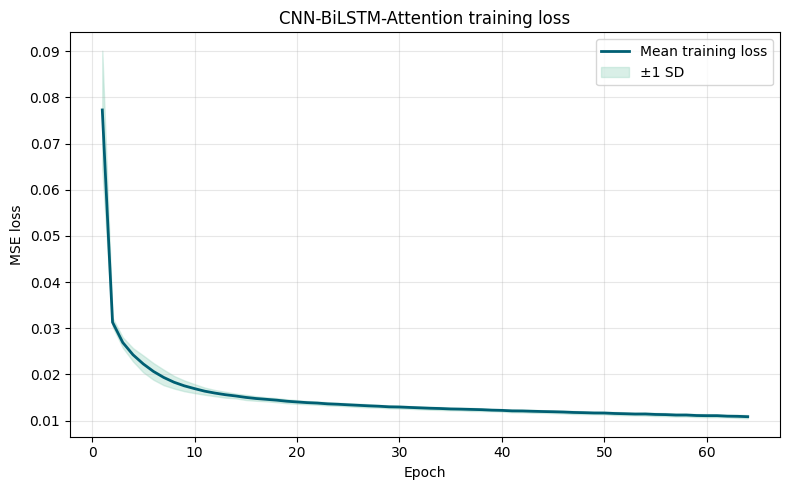

In [8]:
# سلول 7: نمودار میانگین Loss اجراها
history_matrix = np.asarray(history_losses)
mean_loss = history_matrix.mean(axis=0)
std_loss = history_matrix.std(axis=0)
epochs_axis = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, mean_loss, color='#005F73', linewidth=2, label='Mean training loss')
plt.fill_between(epochs_axis, mean_loss-std_loss, mean_loss+std_loss, color='#94D2BD', alpha=0.35, label='±1 SD')
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.title('CNN-BiLSTM-Attention training loss')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()


## محاسبه δ و چرخه مأموریت

مطابق رابطه (۷)، δ میانگین قدرمطلق خطا برای نمونه‌هایی است که RUL واقعی آن‌ها کمتر از ۳۰ است. مطابق رابطه (۱۴)، چرخه مأموریت از توزیع گاما با نرخ λ=۲ و شکل k=۳ انتخاب می‌شود؛ مقدار پوشش ۹۸٪ تقریباً ۳٫۷۷ چرخه است.

,parameter,description,value
0,delta,Mean absolute error for true RUL < 30,3.508546
1,mission_cycle,"Gamma 98% reference for k=3, lambda=2",3.770000
2,lead_time,Spare-part delivery cycle Q,20.000000
3,inspection_interval,Inspection interval,5.000000
4,maintenance_threshold,Delta t + delta,7.278546
5,order_threshold,Q + Delta t + delta,27.278546
6,Cp,Predictive maintenance cost,100.000000
7,Cf,Corrective maintenance cost,500.000000
8,Cos,Out-of-stock cost,10.000000


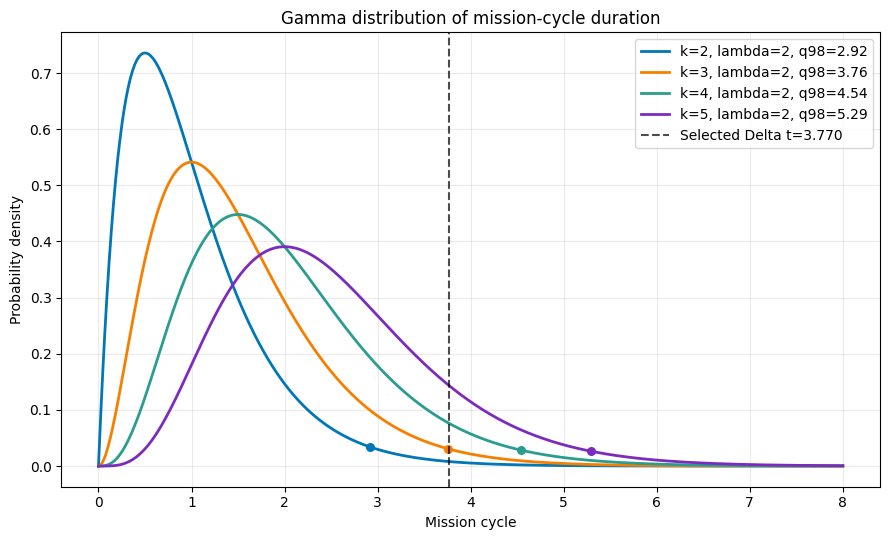

In [9]:
# سلول 8: δ، آستانه‌ها و نمودار توزیع گاما
strategy_prediction = np.maximum(ensemble_prediction, 0.0)
delta_mask = test_true_rul < 30
delta_errors = np.abs(strategy_prediction[delta_mask] - test_true_rul[delta_mask])
delta_value = float(np.mean(delta_errors))
maintenance_threshold = MISSION_CYCLE + delta_value
order_threshold = LEAD_TIME + MISSION_CYCLE + delta_value

delta_details_df = pd.DataFrame({
    "engine_id": test_engine_ids[delta_mask],
    "cycle": test_cycles[delta_mask],
    "actual_rul": test_true_rul[delta_mask],
    "predicted_rul": strategy_prediction[delta_mask],
    "absolute_error": delta_errors,
})
delta_details_df.to_csv(OUTPUT_DIR / "03_delta_details.csv", index=False)

parameter_df = pd.DataFrame([
    ["delta", "Mean absolute error for true RUL < 30", delta_value],
    ["mission_cycle", "Gamma 98% reference for k=3, lambda=2", MISSION_CYCLE],
    ["lead_time", "Spare-part delivery cycle Q", LEAD_TIME],
    ["inspection_interval", "Inspection interval", INSPECTION_INTERVAL],
    ["maintenance_threshold", "Delta t + delta", maintenance_threshold],
    ["order_threshold", "Q + Delta t + delta", order_threshold],
    ["Cp", "Predictive maintenance cost", CP],
    ["Cf", "Corrective maintenance cost", CF],
    ["Cos", "Out-of-stock cost", COS],
], columns=["parameter", "description", "value"])
parameter_df.to_csv(OUTPUT_DIR / "04_strategy_parameters.csv", index=False)
display(parameter_df)

x = np.linspace(0, 8, 700)
plt.figure(figsize=(9, 5.5))
colors = ["#0077B6", "#F77F00", "#2A9D8F", "#7B2CBF"]
for k, color in zip([2, 3, 4, 5], colors):
    y = gamma_dist.pdf(x, a=k, scale=1/GAMMA_RATE)
    q98 = gamma_dist.ppf(0.98, a=k, scale=1/GAMMA_RATE)
    plt.plot(x, y, linewidth=2, color=color, label=f"k={k}, lambda=2, q98={q98:.2f}")
    plt.scatter([q98], [gamma_dist.pdf(q98, a=k, scale=1/GAMMA_RATE)], color=color, s=30)
plt.axvline(MISSION_CYCLE, color="black", linestyle="--", alpha=0.7, label="Selected Delta t=3.770")
plt.xlabel("Mission cycle"); plt.ylabel("Probability density")
plt.title("Gamma distribution of mission-cycle duration")
plt.grid(alpha=0.25); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_gamma_mission_cycle.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# سلول 9: تابع کامل تصمیم سفارش، موجودی و نگهداری
prediction_df = pd.DataFrame({
    "engine_id": test_engine_ids,
    "cycle": test_cycles,
    "true_rul": test_true_rul,
    "true_rul_capped": test_true_rul_capped,
    "predicted_rul": strategy_prediction,
    "lifetime": test_lifetimes,
})


def run_strategy(pred_df, mission_cycle, delta, lead_time=20.0, inspection_interval=5):
    maint_threshold = mission_cycle + delta
    ord_threshold = lead_time + mission_cycle + delta
    decisions, summaries = [], []

    for engine_id in sorted(pred_df.engine_id.unique()):
        e = pred_df[pred_df.engine_id == engine_id].sort_values("cycle").reset_index(drop=True)
        lifetime = int(e.lifetime.iloc[0])
        inspections = e[e.cycle.astype(int) % int(inspection_interval) == 0]
        ordered, spare = 0, 0
        order_cycle = arrival_cycle = maintenance_cycle = None
        maintenance_type = None
        final_shortage = 0
        completed = False

        for _, row in inspections.iterrows():
            cycle = int(row.cycle); true_rul = float(row.true_rul)
            pred = max(float(row.predicted_rul), 0.0)
            order_event = maintenance_event = shortage = 0

            if ordered and not spare and arrival_cycle is not None and cycle >= arrival_cycle:
                spare = 1

            if cycle >= lifetime or true_rul <= 0:
                maintenance_event = 1; maintenance_cycle = lifetime
                maintenance_type = "Corrective maintenance"
                shortage = int(spare == 0); final_shortage = shortage
                decision = "Corrective maintenance" + (" with out-of-stock" if shortage else "")
                n_star, gamma_star = 0, np.nan
                decisions.append(locals_to_decision(engine_id, lifetime, lifetime, 0.0, pred, n_star, gamma_star,
                                                    order_event, ordered, order_cycle, arrival_cycle, spare,
                                                    maintenance_event, shortage, decision))
                completed = True
                break

            ratio = pred / mission_cycle
            n_star = int(np.floor(ratio))
            # رابطه (9) مقاله فقط برای n*=1 تعریف شده است.
            gamma_star = float(ratio - np.floor(ratio)) if n_star == 1 else np.nan
            early_recommendation = int(n_star == 1 and gamma_star <= RELIABILITY_THRESHOLD)

            if pred <= maint_threshold:
                maintenance_event = 1; maintenance_cycle = cycle
                maintenance_type = "Predictive maintenance"
                shortage = int(spare == 0); final_shortage = shortage
                decision = "Predictive maintenance" + (" with out-of-stock" if shortage else "")
                decisions.append(locals_to_decision(engine_id, lifetime, cycle, true_rul, pred, n_star, gamma_star,
                                                    order_event, ordered, order_cycle, arrival_cycle, spare,
                                                    maintenance_event, shortage, decision, early_recommendation))
                completed = True
                break

            decision = "Continue operation"
            if not ordered and pred <= ord_threshold:
                ordered = 1; order_event = 1; order_cycle = cycle
                arrival_cycle = int(np.ceil(cycle + lead_time))
                decision = "Order spare part"

            decisions.append(locals_to_decision(engine_id, lifetime, cycle, true_rul, pred, n_star, gamma_star,
                                                order_event, ordered, order_cycle, arrival_cycle, spare,
                                                maintenance_event, shortage, decision, early_recommendation))

        if not completed:
            if ordered and arrival_cycle is not None and lifetime >= arrival_cycle:
                spare = 1
            shortage = int(spare == 0); final_shortage = shortage
            maintenance_cycle = lifetime; maintenance_type = "Corrective maintenance"
            decision = "Corrective maintenance" + (" with out-of-stock" if shortage else "")
            decisions.append(locals_to_decision(engine_id, lifetime, lifetime, 0.0, np.nan, 0, np.nan,
                                                0, ordered, order_cycle, arrival_cycle, spare, 1, shortage, decision))

        summaries.append({
            "engine_id": int(engine_id), "lifetime": lifetime,
            "order_cycle": order_cycle, "arrival_cycle": arrival_cycle,
            "maintenance_cycle": maintenance_cycle, "maintenance_type": maintenance_type,
            "spare_part_status": spare, "out_of_stock": final_shortage,
        })
    return pd.DataFrame(decisions), pd.DataFrame(summaries)


def locals_to_decision(engine_id, lifetime, cycle, true_rul, pred, n_star, gamma_star,
                       order_event, order_status, order_cycle, arrival_cycle, spare,
                       maintenance_event, shortage, decision, early_recommendation=0):
    return {
        "engine_id": int(engine_id), "lifetime": int(lifetime), "cycle": int(cycle),
        "true_rul": float(true_rul), "predicted_rul": float(pred) if np.isfinite(pred) else np.nan,
        "n_star": int(n_star), "gamma_star_when_n1": gamma_star,
        "early_maintenance_recommendation_gamma_le_0_8": int(early_recommendation),
        "order_event": int(order_event), "order_status": int(order_status),
        "order_cycle": order_cycle, "arrival_cycle": arrival_cycle,
        "spare_part_status": int(spare), "maintenance_event": int(maintenance_event),
        "out_of_stock": int(shortage), "decision": decision,
    }


all_decisions_df, engine_summary_df = run_strategy(
    prediction_df, MISSION_CYCLE, delta_value, LEAD_TIME, INSPECTION_INTERVAL
)
all_decisions_df.to_csv(OUTPUT_DIR / "05_all_strategy_decisions.csv", index=False)
engine_summary_df.to_csv(OUTPUT_DIR / "06_engine_strategy_summary.csv", index=False)

strategy_count_df = pd.DataFrame([{
    "number_of_engines": len(engine_summary_df),
    "number_of_orders": int(engine_summary_df.order_cycle.notna().sum()),
    "number_of_predictive_maintenance": int((engine_summary_df.maintenance_type == "Predictive maintenance").sum()),
    "number_of_corrective_maintenance": int((engine_summary_df.maintenance_type == "Corrective maintenance").sum()),
    "number_of_out_of_stock": int(engine_summary_df.out_of_stock.sum()),
}])
strategy_count_df.to_csv(OUTPUT_DIR / "07_strategy_counts.csv", index=False)
display(strategy_count_df)

,number_of_engines,number_of_orders,number_of_predictive_maintenance,number_of_corrective_maintenance,number_of_out_of_stock
0,20,20,13,7,5


In [11]:
# سلول 10: جدول موتورهای منتخب و قابلیت اطمینان مأموریت آخر
selected_engine_ids = [82, 87, 93, 97]
selected_decisions_df = (
    all_decisions_df[all_decisions_df.engine_id.isin(selected_engine_ids)]
    .groupby("engine_id", group_keys=False).tail(6).reset_index(drop=True)
)
selected_decisions_df.to_csv(OUTPUT_DIR / "08_selected_engine_decisions.csv", index=False)

last_mission_reliability_df = all_decisions_df[
    (all_decisions_df.n_star == 1) & all_decisions_df.gamma_star_when_n1.notna()
].copy()
last_mission_reliability_df.to_csv(OUTPUT_DIR / "09_last_mission_reliability.csv", index=False)

display(selected_decisions_df)
display(last_mission_reliability_df.head(20))

,engine_id,lifetime,cycle,true_rul,predicted_rul,n_star,gamma_star_when_n1,early_maintenance_recommendation_gamma_le_0_8,order_event,order_status,order_cycle,arrival_cycle,spare_part_status,maintenance_event,out_of_stock,decision
0,82,214,185,29.0,33.611247,8,NaN,0,0,0,NaN,NaN,0,0,0,Continue operation
1,82,214,190,24.0,28.116665,7,NaN,0,0,0,NaN,NaN,0,0,0,Continue operation
2,82,214,195,19.0,20.525593,5,NaN,0,1,1,195.0,215.0,0,0,0,Order spare part
3,82,214,200,14.0,14.012692,3,NaN,0,0,1,195.0,215.0,0,0,0,Continue operation
4,82,214,205,9.0,9.046310,2,NaN,0,0,1,195.0,215.0,0,0,0,Continue operation
5,82,214,210,4.0,4.705201,1,0.248064,1,0,1,195.0,215.0,0,1,1,Predictive maintenance with out-of-stock
6,87,178,155,23.0,28.252405,7,NaN,0,0,0,NaN,NaN,0,0,0,Continue operation
7,87,178,160,18.0,15.586813,4,NaN,0,1,1,160.0,180.0,0,0,0,Order spare part
8,87,178,165,13.0,15.192229,4,NaN,0,0,1,160.0,180.0,0,0,0,Continue operation
9,87,178,170,8.0,12.847970,3,NaN,0,0,1,160.0,180.0,0,0,0,Continue operation


,engine_id,lifetime,cycle,true_rul,predicted_rul,n_star,gamma_star_when_n1,early_maintenance_recommendation_gamma_le_0_8,order_event,order_status,order_cycle,arrival_cycle,spare_part_status,maintenance_event,out_of_stock,decision
81,82,214,210,4.0,4.705201,1,0.248064,1,0,1,195.0,215.0,0,1,1,Predictive maintenance with out-of-stock
135,83,293,290,3.0,6.782176,1,0.798986,1,0,1,270.0,290.0,1,1,0,Predictive maintenance
184,84,267,265,2.0,6.368474,1,0.689250,1,0,1,240.0,260.0,1,1,0,Predictive maintenance
269,86,278,275,3.0,6.299966,1,0.671079,1,0,1,250.0,270.0,1,1,0,Predictive maintenance
300,87,178,175,3.0,7.322991,1,0.942438,0,0,1,160.0,180.0,0,0,0,Continue operation
339,88,213,210,3.0,6.022243,1,0.597412,1,0,1,185.0,205.0,1,1,0,Predictive maintenance
378,89,217,215,2.0,5.224539,1,0.385819,1,0,1,200.0,220.0,0,1,1,Predictive maintenance with out-of-stock
491,92,341,335,6.0,6.490855,1,0.721712,1,0,1,305.0,325.0,1,1,0,Predictive maintenance
517,93,155,150,5.0,7.211982,1,0.912993,0,0,1,135.0,155.0,0,1,1,Predictive maintenance with out-of-stock
563,94,258,250,8.0,7.483019,1,0.984886,0,0,1,230.0,250.0,1,0,0,Continue operation


In [12]:
# سلول 11: روابط (11)، (12) و (13) - نرخ هزینه
maintenance_rows = (
    all_decisions_df[all_decisions_df.maintenance_event == 1]
    .sort_values(["engine_id", "cycle"])
    .groupby("engine_id", as_index=False).tail(1)
)
cost_df = engine_summary_df.merge(
    maintenance_rows[["engine_id", "predicted_rul", "true_rul"]], on="engine_id", how="left"
)

rows = []
for _, row in cost_df.iterrows():
    shortage_cost = COS if int(row.out_of_stock) else 0.0
    if row.maintenance_type == "Predictive maintenance":
        predicted_lifetime = float(row.maintenance_cycle) + float(row.predicted_rul)
        denominator = predicted_lifetime - (MISSION_CYCLE + delta_value)
        numerator = CP + shortage_cost
    else:
        predicted_lifetime = np.nan
        denominator = float(row.lifetime)
        numerator = CF + shortage_cost
    rows.append({
        **row.to_dict(), "predicted_lifetime": predicted_lifetime,
        "cost_numerator": numerator, "cost_denominator": denominator,
        "proposed_cost_rate": numerator / denominator,
        "ideal_cost_rate": CP / float(row.lifetime),
    })

cost_df = pd.DataFrame(rows).sort_values("engine_id").reset_index(drop=True)
cost_df["group"] = cost_df.index // 5 + 1
group_cost_df = cost_df.groupby("group", as_index=False).agg(
    first_engine=("engine_id", "min"), last_engine=("engine_id", "max"),
    proposed_cost_rate=("proposed_cost_rate", "mean"),
    ideal_cost_rate=("ideal_cost_rate", "mean"),
)
cost_summary_df = pd.DataFrame([{
    "average_proposed_cost_rate": cost_df.proposed_cost_rate.mean(),
    "average_ideal_cost_rate": cost_df.ideal_cost_rate.mean(),
    "relative_gap_percent": 100 * (cost_df.proposed_cost_rate.mean() - cost_df.ideal_cost_rate.mean()) / cost_df.ideal_cost_rate.mean(),
    "paper_proposed_reference": 0.491,
    "paper_ideal_reference": 0.476,
}])

cost_df.to_csv(OUTPUT_DIR / "10_engine_cost_rates.csv", index=False)
group_cost_df.to_csv(OUTPUT_DIR / "11_group_cost_rates.csv", index=False)
cost_summary_df.to_csv(OUTPUT_DIR / "12_cost_summary.csv", index=False)
display(cost_summary_df)
display(group_cost_df)

,average_proposed_cost_rate,average_ideal_cost_rate,relative_gap_percent,paper_proposed_reference,paper_ideal_reference
0,1.284788,0.476361,169.708818,0.491,0.476


,group,first_engine,last_engine,proposed_cost_rate,ideal_cost_rate
0,1,81,85,1.199459,0.426340
1,2,86,90,1.494495,0.500235
2,3,91,95,1.098488,0.484022
3,4,96,100,1.346708,0.494847


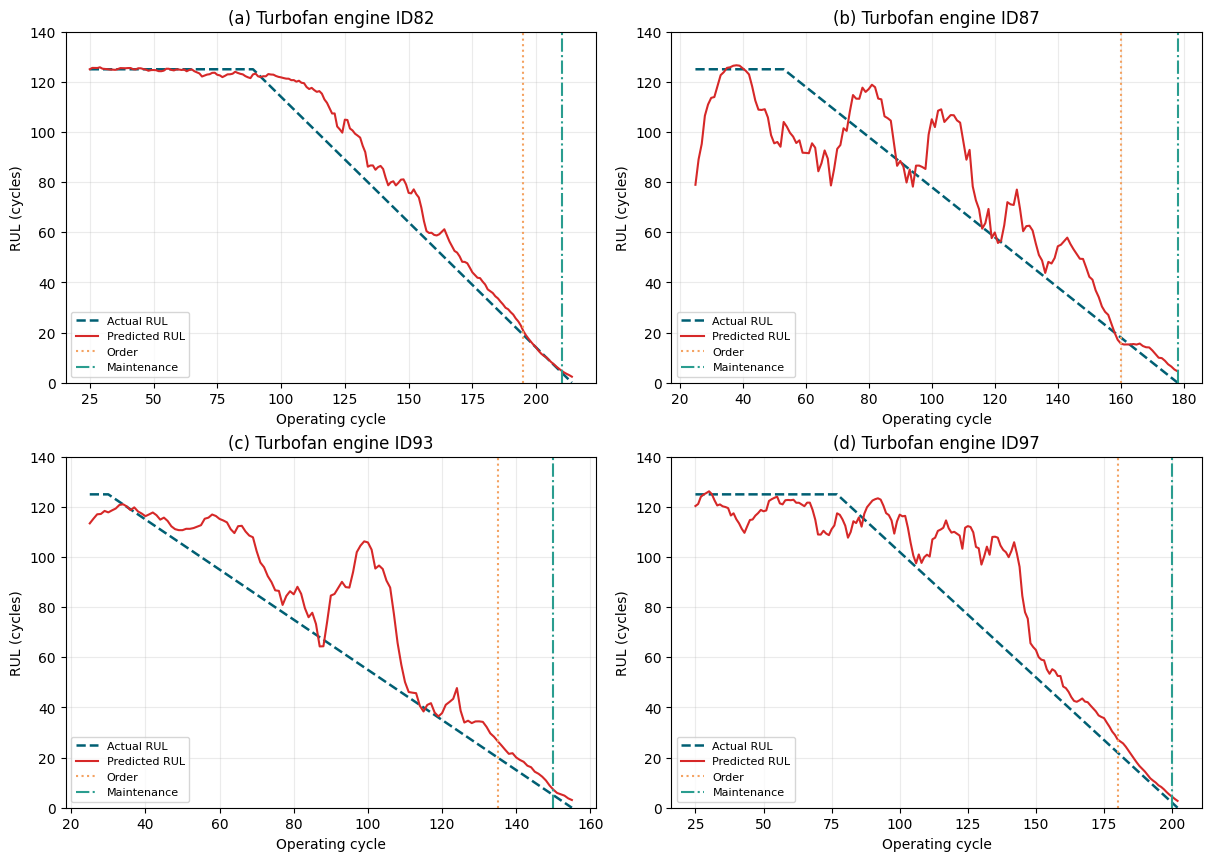

In [13]:
# سلول 12: نمودار RUL واقعی و پیش‌بینی تجمیعی چهار موتور
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), constrained_layout=True)
for ax, engine_id, panel in zip(axes.ravel(), selected_engine_ids, ["(a)", "(b)", "(c)", "(d)"]):
    e = prediction_df[prediction_df.engine_id == engine_id].sort_values("cycle")
    ax.plot(e.cycle, e.true_rul_capped, "--", color="#005F73", linewidth=1.8, label="Actual RUL")
    ax.plot(e.cycle, e.predicted_rul, "-", color="#D62828", linewidth=1.5, label="Predicted RUL")
    summary = engine_summary_df[engine_summary_df.engine_id == engine_id].iloc[0]
    if pd.notna(summary.order_cycle): ax.axvline(summary.order_cycle, color="#F4A261", linestyle=":", label="Order")
    ax.axvline(summary.maintenance_cycle, color="#2A9D8F", linestyle="-.", label="Maintenance")
    ax.set_title(f"{panel} Turbofan engine ID{engine_id}")
    ax.set_xlabel("Operating cycle"); ax.set_ylabel("RUL (cycles)")
    ax.set_ylim(0, 140); ax.grid(alpha=0.25); ax.legend(fontsize=8)
plt.savefig(OUTPUT_DIR / "03_four_engines_rul_and_decisions.png", dpi=300, bbox_inches="tight")
plt.show()

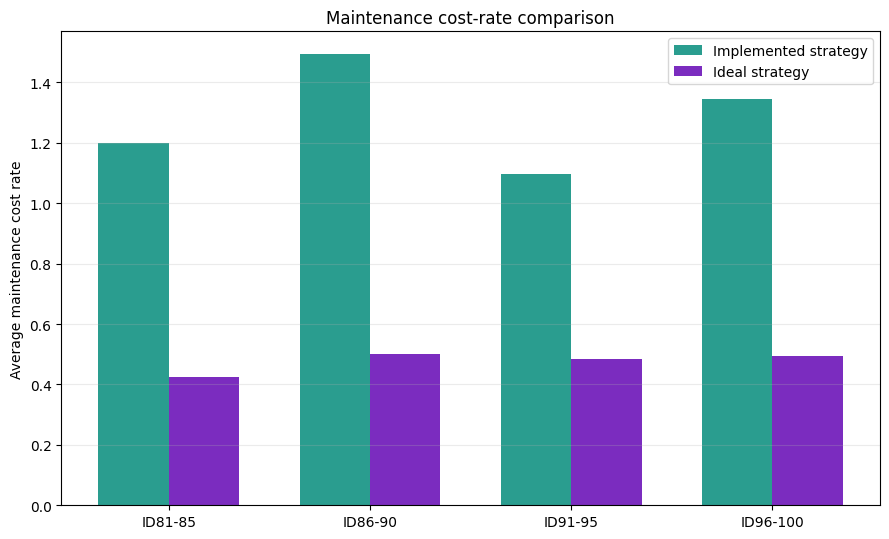

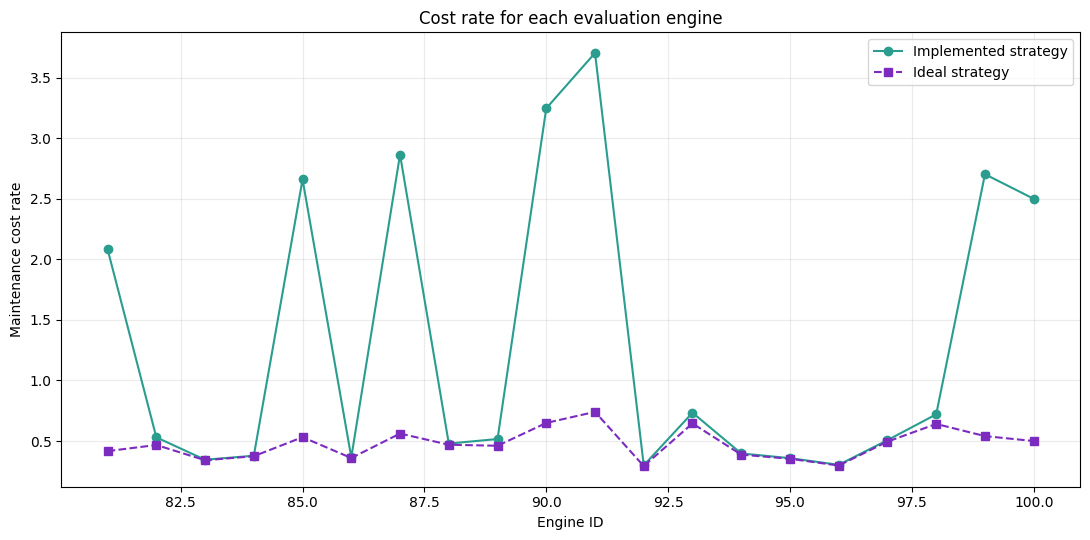

In [14]:
# سلول 13: نمودار مقایسه نرخ هزینه گروه‌ها و هر موتور
labels = [f"ID{int(r.first_engine)}-{int(r.last_engine)}" for _, r in group_cost_df.iterrows()]
xpos = np.arange(len(labels)); width = 0.35
plt.figure(figsize=(9, 5.5))
plt.bar(xpos-width/2, group_cost_df.proposed_cost_rate, width, color="#2A9D8F", label="Implemented strategy")
plt.bar(xpos+width/2, group_cost_df.ideal_cost_rate, width, color="#7B2CBF", label="Ideal strategy")
plt.xticks(xpos, labels); plt.ylabel("Average maintenance cost rate")
plt.title("Maintenance cost-rate comparison")
plt.grid(axis="y", alpha=0.25); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_group_cost_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(11, 5.5))
plt.plot(cost_df.engine_id, cost_df.proposed_cost_rate, "o-", label="Implemented strategy", color="#2A9D8F")
plt.plot(cost_df.engine_id, cost_df.ideal_cost_rate, "s--", label="Ideal strategy", color="#7B2CBF")
plt.xlabel("Engine ID"); plt.ylabel("Maintenance cost rate")
plt.title("Cost rate for each evaluation engine")
plt.grid(alpha=0.25); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_engine_cost_rates.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# سلول 14: تحلیل حساسیت چرخه مأموریت و آستانه δ
mission_cycles = [2.940, 3.770, 4.550, 5.300]
sensitivity_rows = []
for dt in mission_cycles:
    ddf, sdf = run_strategy(prediction_df, dt, delta_value, LEAD_TIME, INSPECTION_INTERVAL)
    sensitivity_rows.append({
        "mission_cycle": dt,
        "orders": int(sdf.order_cycle.notna().sum()),
        "predictive_maintenance": int((sdf.maintenance_type == "Predictive maintenance").sum()),
        "corrective_maintenance": int((sdf.maintenance_type == "Corrective maintenance").sum()),
        "out_of_stock": int(sdf.out_of_stock.sum()),
    })
mission_sensitivity_df = pd.DataFrame(sensitivity_rows)
mission_sensitivity_df.to_csv(OUTPUT_DIR / "13_mission_cycle_sensitivity.csv", index=False)

threshold_rows = []
for label, delta_used in [("Delta_t only", 0.0), ("Delta_t plus delta", delta_value)]:
    ddf, sdf = run_strategy(prediction_df, MISSION_CYCLE, delta_used, LEAD_TIME, INSPECTION_INTERVAL)
    threshold_rows.append({
        "threshold_case": label,
        "delta_used": delta_used,
        "predictive_maintenance": int((sdf.maintenance_type == "Predictive maintenance").sum()),
        "corrective_maintenance": int((sdf.maintenance_type == "Corrective maintenance").sum()),
        "out_of_stock": int(sdf.out_of_stock.sum()),
    })
threshold_sensitivity_df = pd.DataFrame(threshold_rows)
threshold_sensitivity_df.to_csv(OUTPUT_DIR / "14_threshold_sensitivity.csv", index=False)
display(mission_sensitivity_df)
display(threshold_sensitivity_df)

,mission_cycle,orders,predictive_maintenance,corrective_maintenance,out_of_stock
0,2.94,20,11,9,9
1,3.77,20,13,7,5
2,4.55,20,16,4,7
3,5.30,20,17,3,5


,threshold_case,delta_used,predictive_maintenance,corrective_maintenance,out_of_stock
0,Delta_t only,0.000000,2,18,11
1,Delta_t plus delta,3.508546,13,7,5


In [16]:
# سلول 15: ثبت روش و دانلود بسته نهایی نتایج
method_notes = (
    'FD001 dynamic predictive maintenance with temporal additive attention\n\n'
    f'Run mode={RUN_MODE}; runs={N_RUNS}; seeds={SEEDS}.\n'
    f'MAX_RUL={MAX_RUL}, WINDOW_SIZE={WINDOW_SIZE}, MinMax scaling, 14 sensors.\n'
    f'Conv1D(64,kernel=3,ReLU), Dropout={DROPOUT_RATE}, BiLSTM(64,concat),\n'
    f'Temporal Additive Attention(units={ATTENTION_UNITS}), linear Dense,\n'
    f'Adam(lr={LEARNING_RATE}), batch={BATCH_SIZE}, epochs={EPOCHS}.\n\n'
    'The maintenance rules and cost equations are unchanged from the baseline strategy notebook.\n'
    'Engines 1-80 train the model; engines 81-100 are evaluated cycle by cycle.\n'
    'Delta is recomputed from the attention ensemble for true RUL < 30.\n'
    'Parameters: Delta_t=3.770, Q=20, inspection interval=5, Cp=100, Cf=500, Cos=10.\n'
    'A cumulative no-Drive checkpoint was downloaded after completed runs and validated on resume.\n'
)
(OUTPUT_DIR / 'README_method_notes.txt').write_text(method_notes, encoding='utf-8')

zip_path = Path(f'/content/FD001_Attention_dynamic_maintenance_{RUN_MODE}_results.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(OUTPUT_DIR.rglob('*')):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(OUTPUT_DIR))

print('Final results package:', zip_path)
print('Number of result files:', len([p for p in OUTPUT_DIR.rglob('*') if p.is_file()]))
files.download(str(zip_path))


Final results package: /content/FD001_Attention_dynamic_maintenance_final_results.zip
Number of result files: 20


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## روش اجرا و ادامه پس از قطع‌شدن

1. ابتدا با `RUN_MODE='pilot'` و بدون checkpoint اجرا کنید.
2. برای اجرای اصلی مقدار را به `RUN_MODE='final'` تغییر دهید.
3. در اولین اجرای final، سه فایل FD001 را انتخاب کنید.
4. مرورگر باید اجازه دانلود چند فایل از Colab را داشته باشد.
5. بعد از هر seed، آخرین فایل `attention_strategy_cumulative_checkpoint.npz` روی رایانه دانلود می‌شود.
6. اگر Runtime قطع شد، اجرای جدید را با `RUN_MODE='final'` آغاز و سه فایل داده به‌همراه فقط آخرین checkpoint را انتخاب کنید.
7. seedهای قبلی بارگذاری می‌شوند و آموزش از seed بعدی ادامه می‌یابد.

هشدار: checkpoint داخل `/content` پس از قطع Runtime از بین می‌رود؛ نسخه دانلودشده روی رایانه را نگه دارید.
